In [62]:
import pandas as pd
df = pd.read_csv('../data/raw/CHN_TWN2023_2025.csv', low_memory=False)
df = df.drop(columns=['Unnamed: 0'])

In [63]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 165047 entries, 0 to 165046
Data columns (total 61 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   GLOBALEVENTID          165047 non-null  int64  
 1   SQLDATE                165047 non-null  int64  
 2   MonthYear              165047 non-null  int64  
 3   Year                   165047 non-null  int64  
 4   FractionDate           165047 non-null  float64
 5   Actor1Code             165047 non-null  str    
 6   Actor1Name             165047 non-null  str    
 7   Actor1CountryCode      165047 non-null  str    
 8   Actor1KnownGroupCode   0 non-null       float64
 9   Actor1EthnicCode       0 non-null       float64
 10  Actor1Religion1Code    7 non-null       str    
 11  Actor1Religion2Code    0 non-null       float64
 12  Actor1Type1Code        22410 non-null   str    
 13  Actor1Type2Code        2017 non-null    str    
 14  Actor1Type3Code        0 non-null       float64

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1158337194,20240217,202402,2024,2024.1288,CHN,CHINA,CHN,NaN,NaN,...,4,"Bangkok, Krung Thep Mahanakhon, Thailand",TH,TH40,26423,13.7500,100.5170,-3250083,20240217074500,https://www.scmp.com/news/china/diplomacy/arti...
1,1158336208,20240217,202402,2024,2024.1288,TWN,TAIWAN,TWN,NaN,NaN,...,1,North Korea,KN,KN,NaN,40.0000,127.0000,KN,20240217073000,http://www.koreatimes.co.kr/www/world/2024/02/...
2,1158405996,20240217,202402,2024,2024.1288,TWN,TAIWANESE,TWN,NaN,NaN,...,4,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20240217174500,https://news.yahoo.com/g7-demands-russia-expla...
3,1158337195,20240217,202402,2024,2024.1288,CHN,CHINA,CHN,NaN,NaN,...,1,Ukraine,UP,UP,NaN,49.0000,32.0000,UP,20240217074500,https://www.scmp.com/news/china/diplomacy/arti...
4,1158405999,20240217,202402,2024,2024.1288,TWN,TAIWANESE,TWN,NaN,NaN,...,4,"Moscow, Moskva, Russia",RS,RS48,25106,55.7522,37.6156,-2960561,20240217174500,https://news.yahoo.com/g7-demands-russia-expla...


In [64]:
df_eda = df[[
    # 時間
    'SQLDATE', 'MonthYear', 'Year',
    # 國家
    'Actor1CountryCode', 'Actor2CountryCode',
    # 事件類型
    'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
    # 事件強度
    'GoldsteinScale', 'AvgTone',
    # 關注度
    'NumMentions', 'NumSources', 'NumArticles'
]]

df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 165047 entries, 0 to 165046
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SQLDATE            165047 non-null  int64  
 1   MonthYear          165047 non-null  int64  
 2   Year               165047 non-null  int64  
 3   Actor1CountryCode  165047 non-null  str    
 4   Actor2CountryCode  165047 non-null  str    
 5   EventCode          165047 non-null  int64  
 6   EventBaseCode      165047 non-null  int64  
 7   EventRootCode      165047 non-null  int64  
 8   QuadClass          165047 non-null  int64  
 9   GoldsteinScale     165047 non-null  float64
 10  AvgTone            165047 non-null  float64
 11  NumMentions        165047 non-null  int64  
 12  NumSources         165047 non-null  int64  
 13  NumArticles        165047 non-null  int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 18.6 MB


In [65]:
df_eda['date'] = pd.to_datetime(df_eda['SQLDATE'], format='%Y%m%d')
df_eda['MonthYear']

0         202402
1         202402
2         202402
3         202402
4         202402
           ...  
165042    202301
165043    202301
165044    202301
165045    202301
165046    202301
Name: MonthYear, Length: 165047, dtype: int64

In [ ]:
monthly_count = df_eda.groupby('MonthYear').size()
monthly_count

MonthYear
202301     3435
202302     3388
202303     8571
202304    16695
202305     4983
202306     6030
202307     3832
202308     5632
202309     5186
202310     3485
202311     3554
202312     3857
202401     9300
202402     3994
202403     3860
202404     5100
202405     6929
202406     4645
202407     4150
202408     3215
202409     3633
202410     5697
202411     3456
202412     4640
202501     3365
202502     2992
202503     3112
202504     3831
202505     3226
202506     1454
202507     2669
202508     2177
202509     2630
202510     3588
202511     4196
202512     4540
dtype: int64

In [24]:
monthly_goldstein = df_eda.groupby('MonthYear')['GoldsteinScale'].mean()
monthly_goldstein

MonthYear
202301   -0.184105
202302    0.115024
202303    0.450671
202304   -0.753357
202305   -0.005459
202306    0.224594
202307   -0.223121
202308   -0.139560
202309   -0.171732
202310    0.243960
202311    0.338464
202312    0.129375
202401    0.102677
202402   -0.094792
202403    0.297098
202404    0.779882
202405   -0.573402
202406   -0.285856
202407   -0.425012
202408   -0.235863
202409   -0.147812
202410   -0.596840
202411    0.148987
202412    0.015517
202501   -0.191649
202502   -0.892045
202503   -0.668445
202504   -0.583268
202505   -0.108896
202506   -0.782393
202507   -1.188647
202508    0.294947
202509   -0.005323
202510    0.305602
202511   -0.661773
202512   -1.108965
Name: GoldsteinScale, dtype: float64

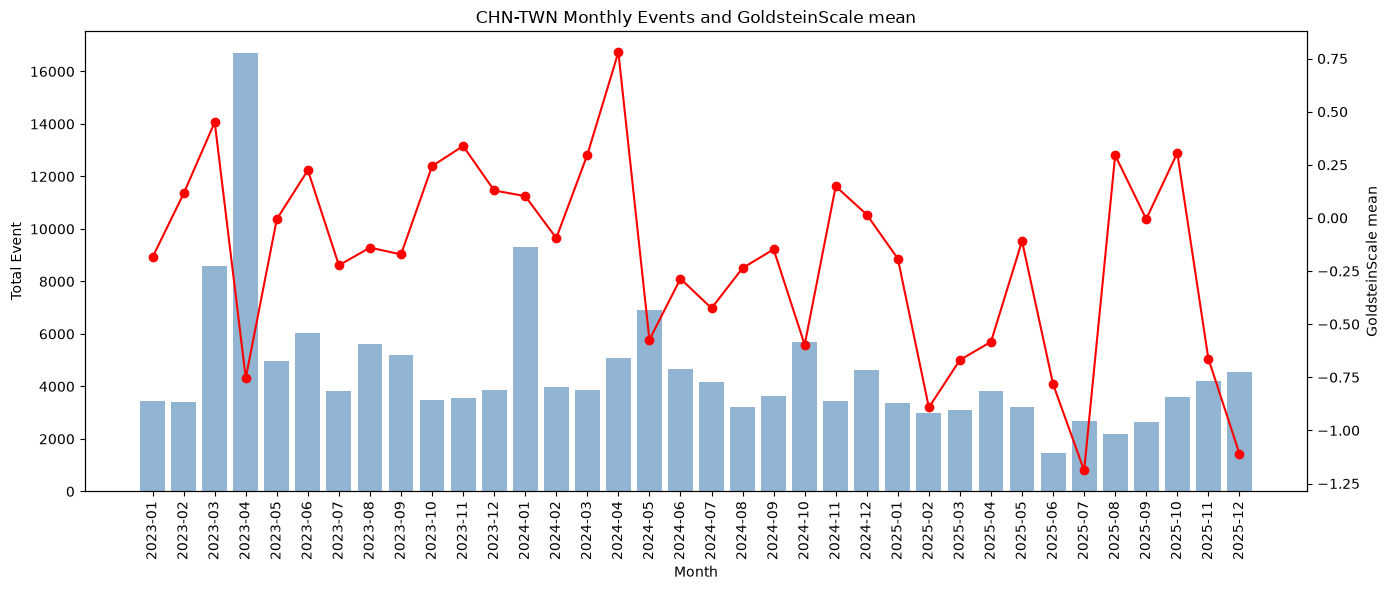

In [67]:
import matplotlib.pyplot as plt

# 先把 labels 算好，放在最前面
labels = monthly_count.index.astype(str).str[:4] + '-' + monthly_count.index.astype(str).str[4:]

fig, ax1 = plt.subplots(figsize=(14, 6))

# 左軸畫事件數量，x 軸直接用 labels
ax1.bar(labels, monthly_count.values, color='steelblue', alpha=0.6, label='Events')
ax1.set_ylabel('Total Event')
ax1.set_xlabel('Month')

# 建立共用 x 軸、獨立 y 軸的第二個圖層，x 軸也用 labels
ax2 = ax1.twinx()
ax2.plot(labels, monthly_goldstein.values, color='red', marker='o', label='Goldstein mean')
ax2.set_ylabel('GoldsteinScale mean')
ax1.tick_params(axis='x', rotation=90)
plt.title('CHN-TWN Monthly Events and GoldsteinScale mean')
plt.tight_layout()
plt.show()

In [ ]:
quad_table = pd.crosstab(df_eda['MonthYear'], df_eda['QuadClass'])
quad_pt = quad_table.div(quad_table.sum(axis=1), axis=0)
print(quad_pt[4]) # 物質衝突

MonthYear
202301    0.147016
202302    0.124852
202303    0.092405
202304    0.183408
202305    0.136865
202306    0.116086
202307    0.164927
202308    0.134055
202309    0.130929
202310    0.104161
202311    0.098199
202312    0.098004
202401    0.088710
202402    0.101152
202403    0.100777
202404    0.061373
202405    0.164959
202406    0.139720
202407    0.188675
202408    0.173561
202409    0.132122
202410    0.173951
202411    0.125579
202412    0.137931
202501    0.141456
202502    0.177139
202503    0.159383
202504    0.179588
202505    0.141662
202506    0.158184
202507    0.197452
202508    0.087735
202509    0.112928
202510    0.086120
202511    0.109390
202512    0.189427
Name: 4, dtype: float64
